# EDA — Fuente 1: data.csv
**Proyecto:** DataMart S.A.S. — Pipeline ETL  
**Archivo:** `data/data.csv`  
**Objetivo:** Explorar la fuente, identificar problemas de calidad y documentar decisiones para el pipeline.

## 1. Importar librerías y cargar datos

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Ruta relativa desde la carpeta notebooks/
FILE_PATH = '../data/raw/datadiario.csv'

df = pd.read_csv(FILE_PATH, encoding='latin1')
print(f'✅ Archivo cargado correctamente')
print(f'   Filas: {df.shape[0]:,}')
print(f'   Columnas: {df.shape[1]}')

✅ Archivo cargado correctamente
   Filas: 541,909
   Columnas: 8


## 2. Vista general — estructura y tipos de dato

In [18]:
print('=== PRIMERAS 5 FILAS ===')
df.head()

=== PRIMERAS 5 FILAS ===


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [19]:
print('=== TIPOS DE DATO ===')
print(df.dtypes)
print()
print('=== INFO GENERAL ===')
df.info()

=== TIPOS DE DATO ===
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

=== INFO GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [20]:
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe(include='all')

=== ESTADÍSTICAS DESCRIPTIVAS ===


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/2011 14:41,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


## 3. Análisis de valores nulos

=== VALORES NULOS POR COLUMNA ===
              Nulos  % del total
InvoiceNo         0         0.00
StockCode         0         0.00
Description    1454         0.27
Quantity          0         0.00
InvoiceDate       0         0.00
UnitPrice         0         0.00
CustomerID   135080        24.93
Country           0         0.00



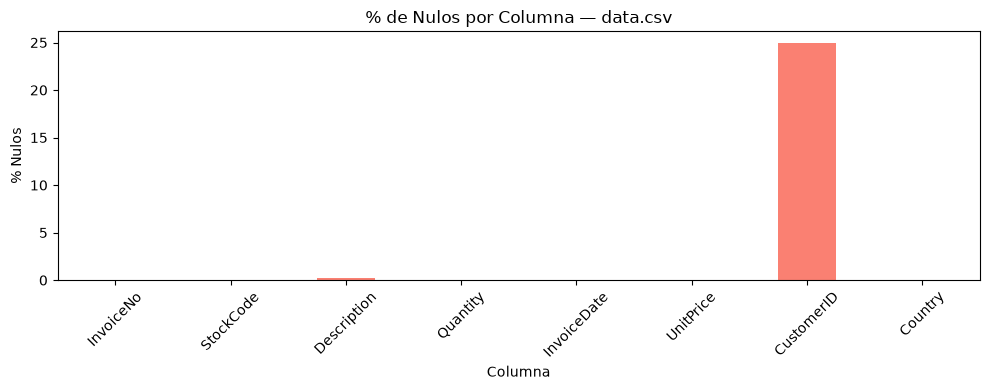

📊 Gráfico guardado en grafics/


In [21]:
nulos = df.isnull().sum()
pct_nulos = (df.isnull().sum() / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    '% del total': pct_nulos
})

print('=== VALORES NULOS POR COLUMNA ===')
print(resumen_nulos)
print()

# Visualización
ax = resumen_nulos['% del total'].plot(kind='bar', color='salmon', figsize=(10, 4))
ax.set_title('% de Nulos por Columna — data.csv')
ax.set_ylabel('% Nulos')
ax.set_xlabel('Columna')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../grafics/nulos_data_csv.png', dpi=100)
plt.show()
print('📊 Gráfico guardado en grafics/')

In [22]:
# Decisión: transacciones sin CustomerID
sin_cliente = df[df['CustomerID'].isnull()]
print(f'Transacciones SIN CustomerID: {len(sin_cliente):,}')
print(f'Porcentaje del total: {len(sin_cliente)/len(df)*100:.2f}%')
print()
print('Distribución por país de transacciones sin cliente:')
print(sin_cliente['Country'].value_counts().head(10))
print()
print('>>> DECISIÓN: se asignará CustomerID = "GUEST" para conservar el revenue.')

Transacciones SIN CustomerID: 135,080
Porcentaje del total: 24.93%

Distribución por país de transacciones sin cliente:
Country
United Kingdom    133600
EIRE                 711
Hong Kong            288
Unspecified          202
Switzerland          125
France                66
Israel                47
Portugal              39
Bahrain                2
Name: count, dtype: int64

>>> DECISIÓN: se asignará CustomerID = "GUEST" para conservar el revenue.


## 4. Análisis de Quantity — ventas vs devoluciones

In [23]:
ventas    = df[df['Quantity'] > 0]
devoluciones = df[df['Quantity'] <= 0]

print(f'Ventas normales  (Quantity > 0):  {len(ventas):,}')
print(f'Devoluciones     (Quantity <= 0): {len(devoluciones):,}')
print(f'Porcentaje devoluciones: {len(devoluciones)/len(df)*100:.2f}%')
print()
print('Distribución de Quantity en ventas:')
print(ventas['Quantity'].describe())
print()
print('Distribución de Quantity en devoluciones:')
print(devoluciones['Quantity'].describe())

Ventas normales  (Quantity > 0):  531,285
Devoluciones     (Quantity <= 0): 10,624
Porcentaje devoluciones: 1.96%

Distribución de Quantity en ventas:
count    531285.000000
mean         10.655262
std         156.830323
min           1.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

Distribución de Quantity en devoluciones:
count    10624.000000
mean       -45.607210
std       1092.214216
min     -80995.000000
25%        -10.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64


In [24]:
# Identificar facturas de devolución (empiezan con C)
invoices_c = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print(f'Facturas que empiezan con C (cancelaciones): {len(invoices_c):,}')
print(f'De esas, cuántas tienen Quantity negativa: {(invoices_c["Quantity"] < 0).sum():,}')
print()
print('>>> DECISIÓN: Quantity <= 0 se clasifica como is_return=TRUE en fact_transactions.')

Facturas que empiezan con C (cancelaciones): 9,288
De esas, cuántas tienen Quantity negativa: 9,288

>>> DECISIÓN: Quantity <= 0 se clasifica como is_return=TRUE en fact_transactions.


## 5. Análisis de UnitPrice — registros a rechazar

In [25]:
precio_cero = df[df['UnitPrice'] == 0]
precio_neg  = df[df['UnitPrice'] < 0]

print(f'Registros con UnitPrice = 0:  {len(precio_cero):,}')
print(f'Registros con UnitPrice < 0:  {len(precio_neg):,}')
print(f'Total a rechazar por precio:  {len(precio_cero) + len(precio_neg):,}')
print()
print('Ejemplos con precio 0:')
print(precio_cero[['InvoiceNo','StockCode','Description','Quantity','UnitPrice']].head(5))
print()
print('>>> DECISIÓN: estos registros van a stg_rejected_records con motivo "precio_invalido".')

Registros con UnitPrice = 0:  2,515
Registros con UnitPrice < 0:  2
Total a rechazar por precio:  2,517

Ejemplos con precio 0:
     InvoiceNo StockCode Description  Quantity  UnitPrice
622     536414     22139         NaN        56        0.0
1970    536545     21134         NaN         1        0.0
1971    536546     22145         NaN         1        0.0
1972    536547     37509         NaN         1        0.0
1987    536549    85226A         NaN         1        0.0

>>> DECISIÓN: estos registros van a stg_rejected_records con motivo "precio_invalido".


## 6. Análisis de StockCode — códigos de producto

In [26]:
total_codigos = df['StockCode'].nunique()
print(f'Total de códigos únicos de producto: {total_codigos:,}')
print()

# Códigos que empiezan con letra (no siguen patrón numérico)
codigos_con_letra = df[df['StockCode'].astype(str).str.match(r'^[A-Za-z]')]
print(f'Registros con StockCode que empieza con letra: {len(codigos_con_letra):,}')
print('Ejemplos:')
print(codigos_con_letra[['StockCode','Description']].drop_duplicates().head(15))
print()
print('>>> DECISIÓN: se normalizan a UPPERCASE sin espacios. Se incluyen en el pipeline si tienen precio válido.')

Total de códigos únicos de producto: 4,070

Registros con StockCode que empieza con letra: 2,995
Ejemplos:
          StockCode                         Description
45             POST                             POSTAGE
141               D                            Discount
1423             C2                            CARRIAGE
1814            DOT                      DOTCOM POSTAGE
2239              M                              Manual
4406   BANK CHARGES                        Bank Charges
14436             S                             SAMPLES
14514     AMAZONFEE                          AMAZON FEE
21326      DCGS0076        SUNJAR LED NIGHT NIGHT LIGHT
24906      DCGS0003                 BOXED GLASS ASHTRAY
38248  gift_0001_40  Dotcomgiftshop Gift Voucher £40.00
40052      DCGS0070               CAMOUFLAGE DOG COLLAR
40383             m                              Manual
42057  gift_0001_50  Dotcomgiftshop Gift Voucher £50.00
44725  gift_0001_30  Dotcomgiftshop Gift Voucher £30.

## 7. Análisis de descripciones — nombre canónico

In [27]:
# Variaciones de descripción por StockCode
variaciones = (
    df.dropna(subset=['Description'])
    .groupby('StockCode')['Description']
    .nunique()
    .reset_index()
    .rename(columns={'Description': 'num_variaciones'})
)

con_variaciones = variaciones[variaciones['num_variaciones'] > 1]
print(f'Códigos con más de 1 descripción distinta: {len(con_variaciones):,}')
print()
print('Top 10 con más variaciones:')
print(con_variaciones.sort_values('num_variaciones', ascending=False).head(10))
print()

# Ejemplo concreto
ejemplo_code = con_variaciones.sort_values('num_variaciones', ascending=False).iloc[0]['StockCode']
print(f'Ejemplo — variaciones para StockCode {ejemplo_code}:')
print(df[df['StockCode'] == ejemplo_code]['Description'].value_counts())
print()
print('>>> DECISIÓN: se usa la descripción más frecuente como nombre canónico en dim_product.')

Códigos con más de 1 descripción distinta: 650

Top 10 con más variaciones:
     StockCode  num_variaciones
168      20713                8
1947     23084                7
841      21830                6
3495     85175                6
1990     23131                5
415      21181                5
2189     23343                5
2804    72807A                5
3492     85172                5
1708     22837                4

Ejemplo — variaciones para StockCode 20713:
Description
JUMBO BAG OWLS                  673
wrongly marked. 23343 in box      1
wrongly coded-23343               1
found                             1
Found                             1
wrongly marked 23343              1
Marked as 23343                   1
wrongly coded 23343               1
Name: count, dtype: int64

>>> DECISIÓN: se usa la descripción más frecuente como nombre canónico en dim_product.


In [28]:
# Construir tabla de nombres canónicos
canonical = (
    df.dropna(subset=['Description'])
    .groupby(['StockCode', 'Description'])
    .size()
    .reset_index(name='frecuencia')
    .sort_values('frecuencia', ascending=False)
    .drop_duplicates(subset='StockCode', keep='first')
    .rename(columns={'Description': 'canonical_description'})
    [['StockCode', 'canonical_description', 'frecuencia']]
)

print(f'Tabla canónica generada: {len(canonical):,} productos únicos')
canonical.head(10)

Tabla canónica generada: 3,958 productos únicos


,StockCode,canonical_description,frecuencia
4223,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2302
1554,22423,REGENCY CAKESTAND 3 TIER,2200
4197,85099B,JUMBO BAG RED RETROSPOT,2159
3295,47566,PARTY BUNTING,1727
210,20725,LUNCH BAG RED RETROSPOT,1638
3956,84879,ASSORTED COLOUR BIRD ORNAMENT,1501
1890,22720,SET OF 3 CAKE TINS PANTRY DESIGN,1473
531,21212,PACK OF 72 RETROSPOT CAKE CASES,1385
213,20727,LUNCH BAG BLACK SKULL.,1350
1593,22457,NATURAL SLATE HEART CHALKBOARD,1280


## 8. Análisis de fechas

In [30]:
df['InvoiceDate_parsed'] = pd.to_datetime(df['InvoiceDate'])

print(f'Formato original de fecha: string — "{df["InvoiceDate"].iloc[0]}"')
print(f'Rango de fechas: {df["InvoiceDate_parsed"].min()} → {df["InvoiceDate_parsed"].max()}')
print(f'Años presentes: {sorted(df["InvoiceDate_parsed"].dt.year.unique())}')
print(f'Fechas nulas tras parseo: {df["InvoiceDate_parsed"].isnull().sum()}')
print()
print('>>> DECISIÓN: se parsea con pd.to_datetime() y se convierte a UTC antes de cargar al DW.')

Formato original de fecha: string — "12/1/2010 8:26"
Rango de fechas: 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Años presentes: [np.int32(2010), np.int32(2011)]
Fechas nulas tras parseo: 0

>>> DECISIÓN: se parsea con pd.to_datetime() y se convierte a UTC antes de cargar al DW.


In [31]:
# Transacciones por mes
df['year_month'] = df['InvoiceDate_parsed'].dt.to_period('M')
por_mes = df[df['Quantity'] > 0].groupby('year_month').agg(
    transacciones=('InvoiceNo', 'count'),
    revenue_bruto=('Quantity', lambda x: (x * df.loc[x.index, 'UnitPrice']).sum())
).reset_index()

print('Transacciones y revenue bruto por mes:')
print(por_mes.to_string())

Transacciones y revenue bruto por mes:
   year_month  transacciones  revenue_bruto
0     2010-12          41683     823746.140
1     2011-01          34350     691364.560
2     2011-02          27184     523631.890
3     2011-03          35915     717639.360
4     2011-04          29171     537808.621
5     2011-05          36292     770536.020
6     2011-06          36056     761739.900
7     2011-07          38716     719221.191
8     2011-08          34566     737014.260
9     2011-09          49323    1058590.172
10    2011-10          59396    1154979.300
11    2011-11          83498    1509496.330
12    2011-12          25135     638792.680


## 9. Análisis por país

In [32]:
por_pais = (
    df[df['Quantity'] > 0]
    .groupby('Country')
    .agg(
        transacciones=('InvoiceNo', 'count'),
        clientes_unicos=('CustomerID', 'nunique'),
        revenue_bruto=('Quantity', lambda x: (x * df.loc[x.index, 'UnitPrice']).sum())
    )
    .sort_values('revenue_bruto', ascending=False)
    .reset_index()
)

por_pais['ticket_promedio'] = (por_pais['revenue_bruto'] / por_pais['transacciones']).round(2)

print('Top 10 países por revenue bruto:')
print(por_pais.head(10).to_string())
print()
print(f'Total de países únicos: {df["Country"].nunique()}')

Top 10 países por revenue bruto:
          Country  transacciones  clientes_unicos  revenue_bruto  ticket_promedio
0  United Kingdom         486286             3921    9003097.964            18.51
1     Netherlands           2363                9     285446.340           120.80
2            EIRE           7894                3     283453.960            35.91
3         Germany           9042               94     228867.140            25.31
4          France           8408               87     209715.110            24.94
5       Australia           1185                9     138521.310           116.90
6           Spain           2485               30      61577.110            24.78
7     Switzerland           1967               21      57089.900            29.02
8         Belgium           2031               25      41196.340            20.28
9          Sweden            451                8      38378.330            85.10

Total de países únicos: 38


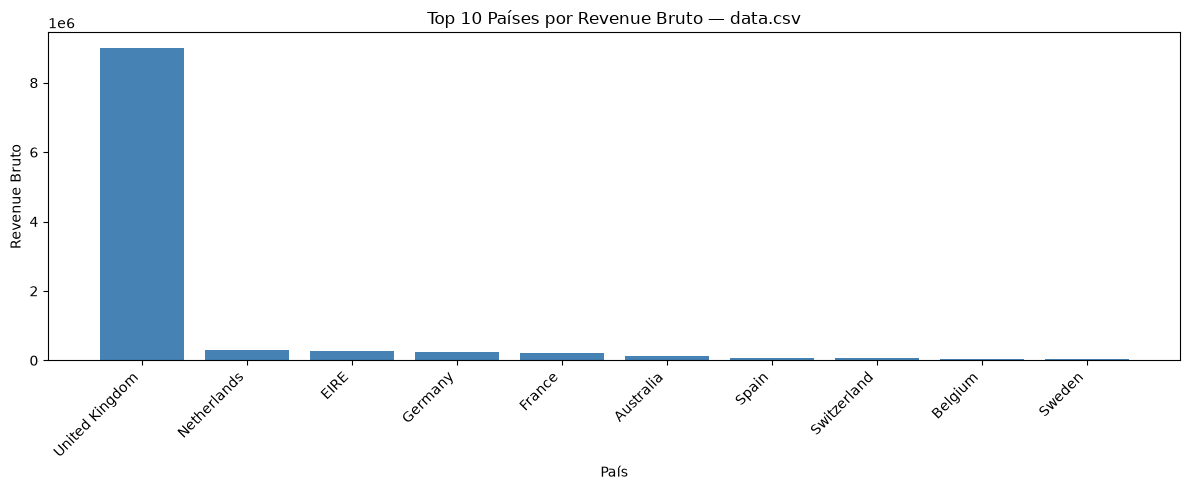

📊 Gráfico guardado en grafics/


In [33]:
# Gráfico top 10 países
top10 = por_pais.head(10)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top10['Country'], top10['revenue_bruto'], color='steelblue')
ax.set_title('Top 10 Países por Revenue Bruto — data.csv')
ax.set_ylabel('Revenue Bruto')
ax.set_xlabel('País')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../grafics/revenue_por_pais_csv.png', dpi=100)
plt.show()
print('📊 Gráfico guardado en grafics/')

## 10. Resumen de calidad — tabla consolidada

In [34]:
resumen = pd.DataFrame([
    {'Problema': 'CustomerID nulo',         'Cantidad': df['CustomerID'].isnull().sum(),          'Decisión': 'Asignar GUEST'},
    {'Problema': 'Description nula',        'Cantidad': df['Description'].isnull().sum(),          'Decisión': 'Mantener si tiene precio válido'},
    {'Problema': 'Quantity <= 0 (devol.)',   'Cantidad': (df['Quantity'] <= 0).sum(),               'Decisión': 'is_return=TRUE'},
    {'Problema': 'UnitPrice = 0',            'Cantidad': (df['UnitPrice'] == 0).sum(),              'Decisión': 'Rechazar → stg_rejected_records'},
    {'Problema': 'UnitPrice < 0',            'Cantidad': (df['UnitPrice'] < 0).sum(),               'Decisión': 'Rechazar → stg_rejected_records'},
    {'Problema': 'StockCode empieza letra',  'Cantidad': df['StockCode'].astype(str).str.match(r'^[A-Za-z]').sum(), 'Decisión': 'Normalizar UPPERCASE'},
    {'Problema': 'Descripciones múltiples',  'Cantidad': len(con_variaciones),                      'Decisión': 'Usar descripción más frecuente'},
])

print('=== RESUMEN DE CALIDAD — data.csv ===')
print(resumen.to_string(index=False))

=== RESUMEN DE CALIDAD — data.csv ===
               Problema  Cantidad                        Decisión
        CustomerID nulo    135080                   Asignar GUEST
       Description nula      1454 Mantener si tiene precio válido
 Quantity <= 0 (devol.)     10624                  is_return=TRUE
          UnitPrice = 0      2515 Rechazar → stg_rejected_records
          UnitPrice < 0         2 Rechazar → stg_rejected_records
StockCode empieza letra      2995            Normalizar UPPERCASE
Descripciones múltiples       650  Usar descripción más frecuente
